# Современные методы анализа данных и машинного обучения, БИ

## НИУ ВШЭ, 2025-26 учебный год

### Домашнее задание №4. Математическая оптимизация

Задание выполнил(а):

    Романцов Александр

### Общая информация

__Дата выдачи:__ 04.05.2026

__Дедлайн:__ 04:00 20.05.2026

### Оценивание и штрафы

Количество баллов за каждую задачу данного домашнего задания указано рядом с условием задачи.

Оценка за домашнее задание вычисляется по следующей формуле:

$$
s \times 10/34 ,
$$

где $s$  — количество баллов, которое вы набрали в сумме по всем задачам.

За сдачу задания позже срока на итоговую оценку за задание накладывается штраф в размере 1 **вторичный** балл в день, но  задержка не может быть больше недели.

**Важно:** В этом домашнем задании предусмотрено несколько заданий, за которые можно получить бонусные баллы. Бонусные баллы прибавляются к обычным баллам, и может выйти так, что ваша итоговая оценка станет больше 10. В таком случае именно это и будет являться вашей оценкой. То есть за это ДЗ **можно** получить больше 10

__Внимание!__ Домашнее задание выполняется самостоятельно. Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов.

Использование в решении домашнего задания генеративных моделей (ChatGPT и так далее) допускается исключительно в рамках справочной и образовательной информации. Любые другие случаи применения средств ИИ — например, для автоматической генерации кода по заданию — считаются плагиатом, и такое домашнее задание оценивается в 0 баллов.

### Формат сдачи

Загрузка файлов с решениями происходит в системе [Anytask](https://anytask.org/). Необходимо загружать файл с расширением .ipynb (питоновский ноутбук)

Инвайт для подключения к странице курса в системе — указан для каждой группы в нашем телеграмм-канале.

### О задании

В данном задании мы потренируемся в работе с математическим анализом и методами математической оптимизации, чёткое понимание которых необходимо в рамках любой задачи и для любой модели в машинном обучении.

В первой части задания мы будем работать со следующей функцией:

$$y(x) = x^{3} \ln(x)$$

### Задание 1


#### 1.1. (1 балл)

Посчитайте производную данной функции аналитически. Для этого либо воспользуйтесь листком бумаги и прикрепите сюда фотографию, либо используйте язык разметки LaTeX — он поддерживается в юпитеровских ноутбуках.

$$
y(x) = x^{3} * \ln(x)
$$
$$
f'(x) = 3 \cdot x^{2} \cdot \ln(x) + \frac{1}{x} \cdot x^{3} \text{  (По правилу произведения)}
$$



#### 1.2. (2 балла)

Напишите программную функцию `f(x)`, которая бы вычисляла значение нашей функции в точке и возвращала бы это значение в качестве ответа; и напишите программную функцию `df(x)`, которая бы вычисляла значение производной нашей функции в точке и возвращала бы это значение в качестве ответа.

Обязательно сделайте проверку всех функций на какой-нибудь конкретной точке. Убедитесь, что ответы вашего предыдущего пункта (на листочке) и программного в этом плане полностью совпадают.

In [5]:
import numpy as np
import matplotlib.pyplot as plt 

In [9]:
def f(x):
    return (x**3) * (np.log(x))

In [10]:
f(1)

np.float64(0.0)

In [22]:
def df(x):
    first = 3 * (x**2) * np.log(x)
    second = (1/x) * (x**3)
    return first + second

In [23]:
df(1)

np.float64(1.0)

#### 1.3. (2 балла)

Визуализируйте нашу функцию (постройте график).

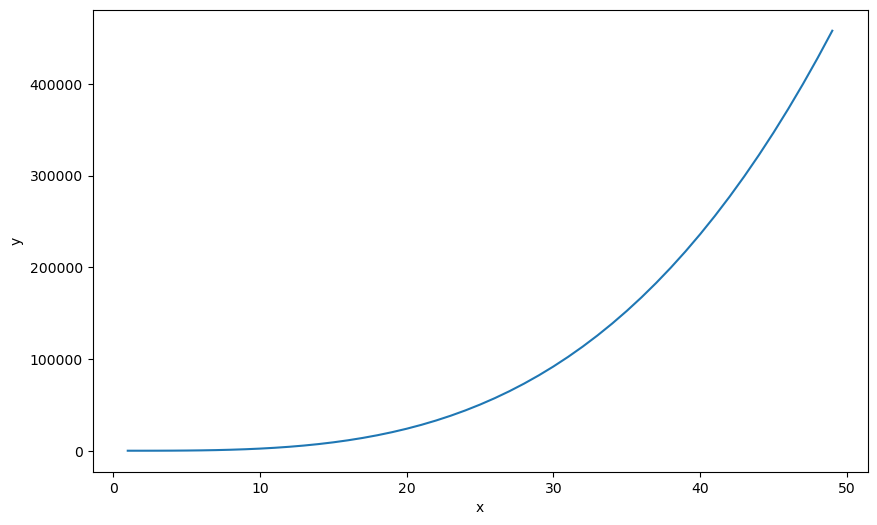

In [14]:
x = np.arange(1, 50, 1)
y = f(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### Задание 2

#### 2.1. (4 балла)

Реализуйте функцию `get_min_with_gd`, которая принимает на вход начальную точку $x_0$, число шагов, `lr` и `threshold`; внутри себя производит поиск минимума при помощи градиентного спуска; и возвращает последовательность точек, полученных на каждом шаге.

In [28]:
def get_min_with_gd(x_0, n_steps, lr, threshold):
    all_x = []
    all_x.append(x_0)
    
    x = x_0
    for s in range(n_steps):
        gradient = df(x)
        if abs(gradient) < threshold:
            break
        x_new = x - lr * gradient
        all_x.append(x_new)
        x = x_new
    return all_x

#### 2.2. (2 балла)

Запустите поиск минимума с нескольких любых точек (не менее 3).

Проверьте, что все работает ожидаемым образом, отрисовав график изменения координаты точки, в зависимости от итерации градиентного спуска, для каждого запуска.

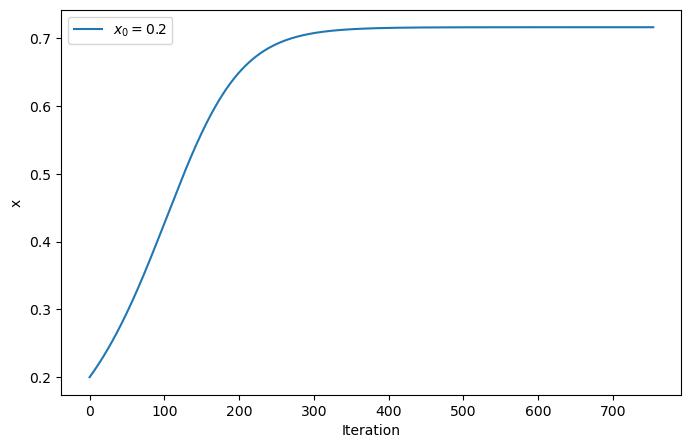

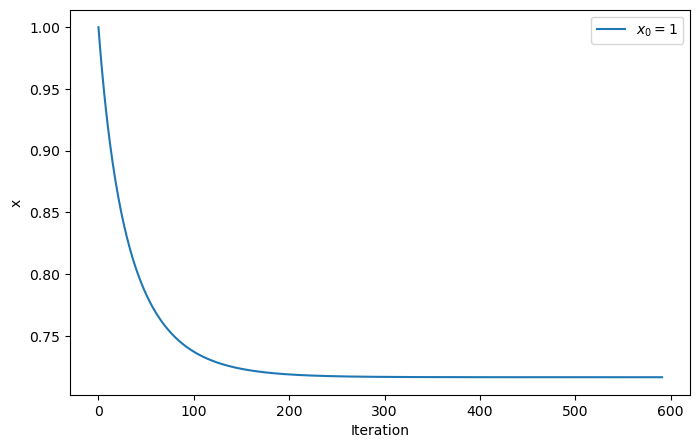

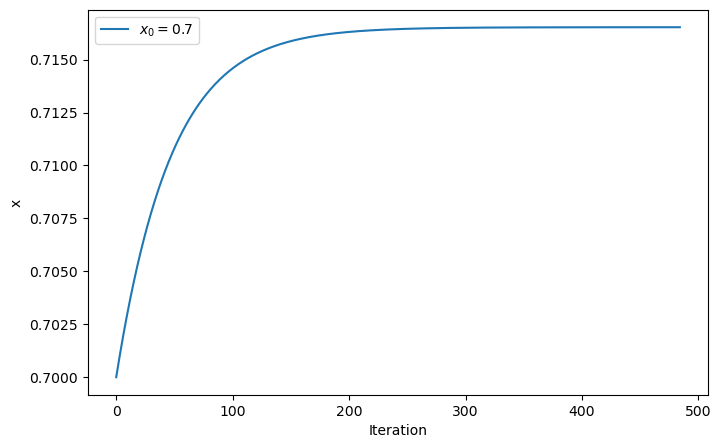

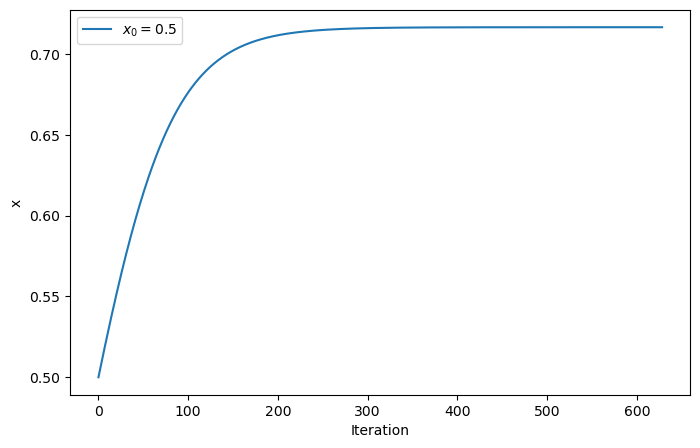

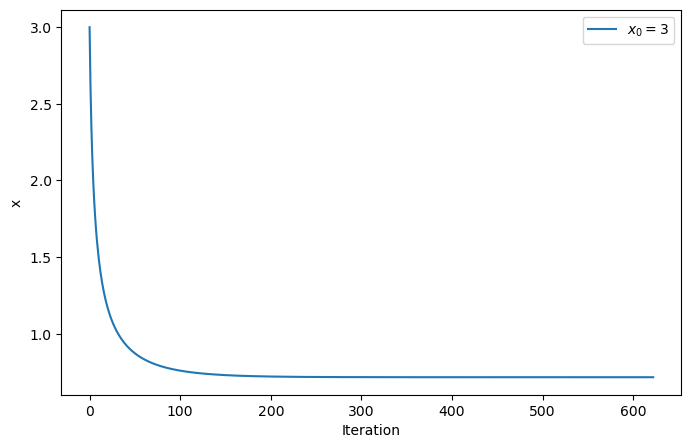

In [30]:
x_starts = [0.2, 1, 0.7, 0.5, 3]
lr = 0.01
threshold = 1e-6
n_steps = 1000
for x_0 in x_starts:
    points = get_min_with_gd(x_0, n_steps=n_steps, lr=lr, threshold=threshold)
    plt.figure(figsize=(8, 5))
    plt.plot(range(len(points)), points, label=f"$x_0 = {x_0}$")
    plt.xlabel("Iteration")
    plt.ylabel("x")
    plt.legend()
    plt.show()

#### 2.3. (3 балла)

Отрисуйте график самой функции еще раз. На данный график нанесите движение алгоритма от исходных точек к финальной точке разными цветами. Нанесите на график истинный минимум отдельной точкой и подпишите его (в виде текста на графике).

In [33]:
x_min = get_min_with_gd(0.7, n_steps=n_steps, lr=lr, threshold=threshold)[-1]
print(x_min)

0.7165308469018629


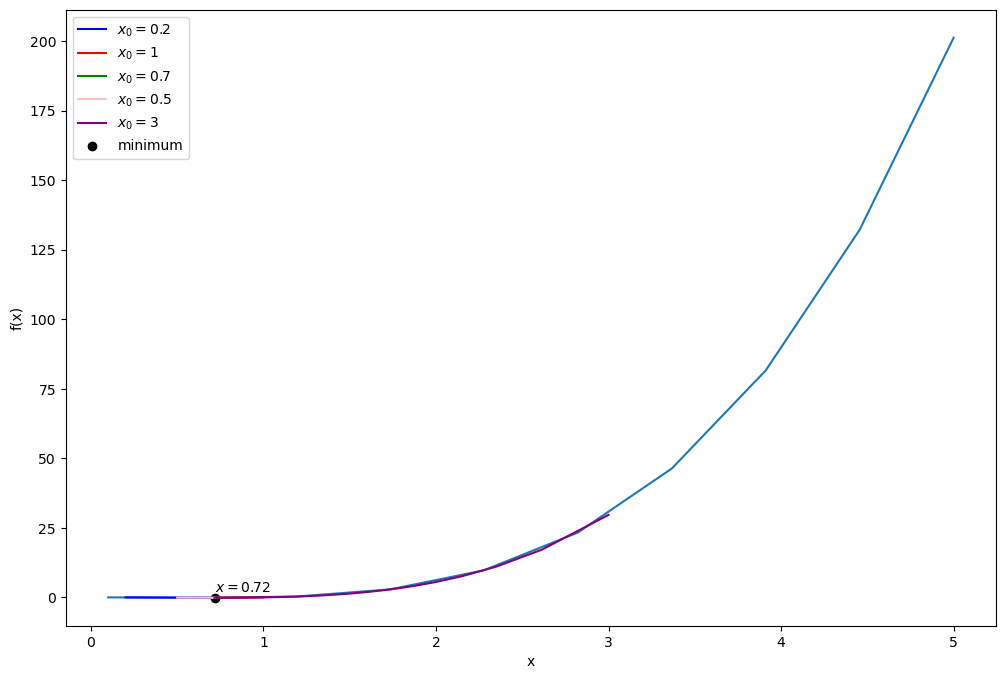

In [44]:
x_grid = np.linspace(0.1, 5, 10)
y_grid = f(x_grid)
plt.figure(figsize=(12, 8))
plt.plot(x_grid, y_grid)
colors = ["blue", "red", "green", "pink", "purple"]

for x_0, color in zip(x_starts, colors):
    points = get_min_with_gd(x_0=x_0, n_steps = n_steps, lr=lr, threshold=threshold)
    points = np.array(points)
    plt.plot(points, f(points), color=color, label=f"$x_0 = {x_0}$")
plt.scatter(x_min, f(x_min), color="black", label="minimum")
plt.text(x_min, f(x_min) + 2, f"$x = {np.round(x_min,2)}$")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()

### Задание 3

Начиная с задания 3, мы будем работать с другими функциями.

Пусть

$$f = \log((e^x + e^{-2x}) \cdot(e^{y + 1} + 0.5\cdot e ^{-y}))$$

#### 3.1. (1 балл и 2 бонусных балла)

Верно ли, что $f$ имеет единственную точку локального минимума, причем этот локальный минимум также является и глобальным? Почему да или почему нет? Докажите ваш ответ!

*Примечание. В данном задании графическое доказательство оценивается в 1 балл; строгое математическое доказательство оценивается в 2 бонусных балла.*

$$f = \log((e^x + e^{-2x}) \cdot(e^{y + 1} + 0.5\cdot e ^{-y}))$$
$$f = \log((e^x + e^{-2x})) + \log(e^{y + 1} + 0.5\cdot e ^{-y})$$
$$g(x) = \log((e^x + e^{-2x})), h(y) = \log(e^{y + 1} + 0.5\cdot e ^{-y})$$
$$f = g(x) + h(y)$$

Тогда мы найдем сначала производную функции от х, а потом от y.

$$g'(x) = \frac{1}{e^x + e^{-2x}} \cdot (e^x + e^{-2x})' = \frac{e^x -2e^{-2x}}{e^x + e^{-2x}}$$
$$g'(x) = \frac{e^x -2e^{-2x}}{e^x + e^{-2x}} = 0$$ 

Дробь будет равна нулю, когда числитель будет равен 0, тогда:
$$e^x -2e^{-2x} = 0$$
$$e^x = 2e^{-2x}$$
$$\log(e^x) = \log(2e^{-2x})$$
$$x = \log(2) -2x $$
$$3x = \log(2)$$
$$x = \frac{\log(2)}{3}$$

Теперь для функции от y:
$$h'(y) = \frac{1}{e^{y + 1} + 0.5\cdot e ^{-y}} \cdot (e^{y + 1} + 0.5\cdot e ^{-y})'$$
$$h'(y) = \frac{1}{e^{y + 1} + 0.5\cdot e ^{-y}} \cdot (e^{y} \cdot e - 0.5\cdot e ^{-y})$$
$$h'(y) = \frac{e^{y + 1} - 0.5\cdot e ^{-y}}{e^{y + 1} + 0.5\cdot e ^{-y}}$$
$$h'(y) = \frac{e^{y + 1} - 0.5\cdot e ^{-y}}{e^{y + 1} + 0.5\cdot e ^{-y}} = 0$$

Также как и в прошлой функции производная будет равна 0, если числитель равен 0:

$$e^{y + 1} - 0.5\cdot e ^{-y} = 0$$
$$e^{y + 1} = 0.5\cdot e ^{-y}$$
$$\log(e^{y + 1}) = \log(0.5\cdot e ^{-y})$$
$$y + 1 = \log(0.5) - y$$
$$2y = \log(0.5) - 1$$
$$y = \frac{\log(0.5) - 1}{2}$$

Доказали, что есть 1 точка минимума!

#### 3.2. (3 балла и 2 бонусных балла)

Придумайте какие-нибудь функции $g$ и $h$ от двух переменных, такие что
- функция $g$ не имеет глобального минимума (не ограничена снизу);
- функция $h$ имеет по крайней мере два локальных минимума, неравных друг другу.

Докажите, что ваши функции удовлетворяют заявленным критериям.

*Примечание. В данном задании графическое доказательство оценивается в рамках основных баллов; строгое математическое доказательство оценивается в 2 бонусных балла.*

In [2]:
def g(x, y):
    return x**3 + y**2

In [3]:
def h(x, y):
    return (x**2 - 1)**2 + y**2

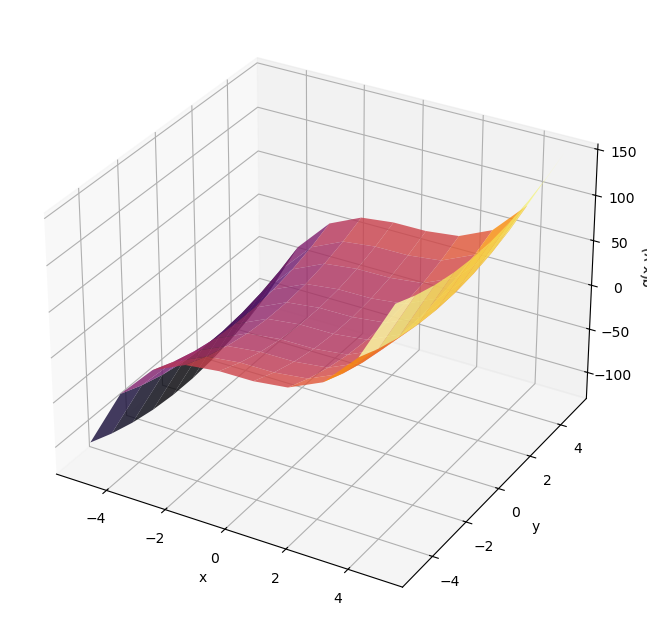

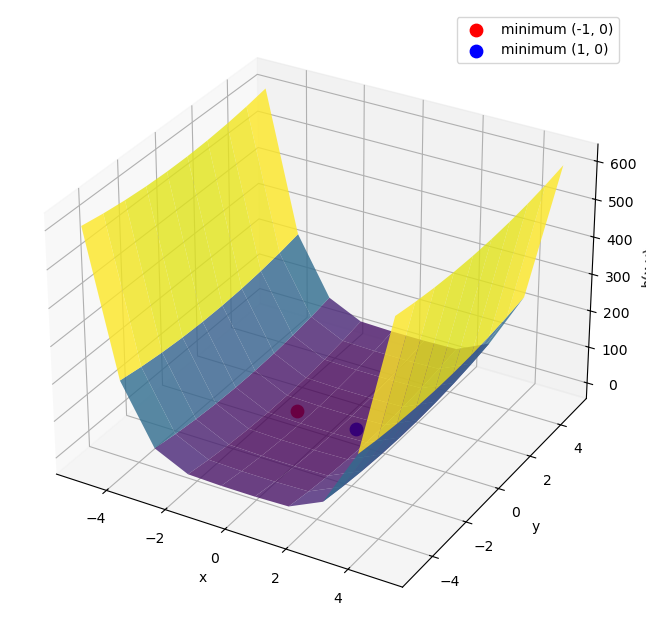

In [6]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
X, Y = np.meshgrid(x, y)
G = g(X, Y)
H = h(X, Y)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(projection="3d")
ax.plot_surface(X, Y, G, cmap="inferno", alpha=0.8)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("g(x,y)")
plt.show()

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(projection="3d")
ax.plot_surface(X, Y, H, cmap="viridis", alpha=0.8)
ax.scatter(-1, 0, h(-1, 0), color="red", s=80, label="minimum (-1, 0)")
ax.scatter(1, 0, h(1, 0), color="blue", s=80, label="minimum (1, 0)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("h(x,y)")

ax.legend()
plt.show()

На графике видно, что у функции $H(x,y)$ как раз два минимума из-за $(x^2 - 1)$, а функция $G(x,y)$ не ограничена снизу, так как если мы устремим например по x в минус бесконечность, то мы получим тоже минус бесконечность, тогда как раз у этой функции и не будет ограничения снизу, так как функция может принимать максимально маленькие значения.

#### 3.3. (5 баллов)

Реализуйте функцию `get_min_with_rmsprop`, которая принимает на вход начальную точку $x_0$, число шагов, `lr`, `beta` и `threshold`; внутри себя производит поиск минимума при помощи градиентного спуска с модификацией RMSProp; и возвращает последовательность точек, полученных на каждом шаге.

Напомним, как выглядят формулы для этого алгоритма:

$$g^{n+1} = ∇f(w^{n})$$
$$\gamma^{n+1} = (1 - \beta) \gamma^{n} + \beta (g^{n+1}) ^ 2$$
$$w^{n+1} = w^n - \frac{\alpha}{\sqrt{\gamma^{n+1} + ɛ}}⋅g^{n+1}$$

Здесь $α$ — learning rate, $ɛ$ — малое число (можно взять 0.0001 — оно нужно, чтобы случайно не было деления на 0), $\beta$ — мера учета инерции.



In [7]:
def get_min_with_rmsprop(x_0, n_steps, lr, beta, threshold):
    all_x = []
    all_x.append(x_0)
    
    x = x_0
    gamma = 0
    eps = 0.0001
    for s in range(n_steps):
        gradient = df(x)
        if abs(gradient) < threshold:
            break
        gamma = (1 - beta) * gamma + beta * (gradient ** 2)
        x_new = x - lr / np.sqrt(gamma + eps) * gradient
        
        all_x.append(x_new)
        x = x_new
    return all_x

#### 3.4. (4 балла)

Запустите поиск минимума для всех трёх функций ($f$, $g$, $h$) с нескольких любых точек (не менее 3 — таким образом, минимум 9 запусков).

Проверьте, что все работает ожидаемым образом, отрисовав для каждого запуска график изменения координат точки (2D-график) по мере прохождения градиентного спуска. Все графики строятся на трёх парах осей, размещенных вертикально на одном полотне (свои оси для каждой функции; разные запуски для одной функции изображаются на одних осях).

In [11]:
def f(x,y):
    return np.log((np.exp(x) + np.exp(-2*x)) * (np.exp(y + 1) + 0.5 * np.exp(-y)))

def gradient_f(x,y):
    dx = (np.exp(x) - 2 * np.exp(-2*x)) / (np.exp(x) + np.exp(-2*x))
    dy = (np.exp(y + 1) - 0.5 * np.exp(-y)) / (np.exp(y + 1) + 0.5 * np.exp(-y))
    return np.array([dx, dy])

In [12]:
def gradient_g(x,y):
    dx = 3 * x**2
    dy = 2 * y
    return np.array([dx, dy])

In [13]:
def gradient_h(x,y):
    dx = 4 * x * (x**2 - 1)
    dy = 2 * y
    return np.array([dx, dy])

In [15]:
def get_min_with_rmsprop(x_0, n_steps, lr, beta, threshold, grad_func):
    x = np.array(x_0, dtype=float)
    gamma = np.zeros_like(x)
    eps = 0.0001
    
    all_x = [x.copy()]
    for s in range(n_steps):
        gradient = grad_func(x[0], x[1])
        
        if np.linalg.norm(gradient) < threshold:
            break
        
        gamma = (1 - beta) * gamma + beta * gradient**2
        x_new = x - lr * gradient / np.sqrt(gamma + eps)
        all_x.append(x_new.copy())
        x = x_new
    return np.array(all_x)

In [16]:
n_steps = 500
lr = 0.01
beta = 0.9
threshold = 1e-6

In [20]:
histories_f = []
histories_f.append(get_min_with_rmsprop(x_0=[1,1], n_steps = n_steps, lr=lr, beta=beta, threshold=threshold, grad_func=gradient_f))
histories_f.append(get_min_with_rmsprop(x_0=[1,5], n_steps = n_steps, lr=lr, beta=beta, threshold=threshold, grad_func=gradient_f))
histories_f.append(get_min_with_rmsprop(x_0=[2,-2], n_steps = n_steps, lr=lr, beta=beta, threshold=threshold, grad_func=gradient_f))

histories_g = []
histories_g.append(get_min_with_rmsprop(x_0=[-1,2], n_steps = n_steps, lr=lr, beta=beta, threshold=threshold, grad_func=gradient_g))
histories_g.append(get_min_with_rmsprop(x_0=[1,-2], n_steps = n_steps, lr=lr, beta=beta, threshold=threshold, grad_func= gradient_g))
histories_g.append(get_min_with_rmsprop(x_0=[2,3], n_steps = n_steps, lr=lr, beta=beta, threshold=threshold, grad_func=gradient_g))

histories_h = []
histories_h.append(get_min_with_rmsprop(x_0=[-1,2], n_steps = n_steps, lr=lr, beta=beta, threshold=threshold, grad_func=gradient_h))
histories_h.append(get_min_with_rmsprop(x_0=[2,2], n_steps = n_steps, lr=lr, beta=beta, threshold=threshold, grad_func=gradient_h))
histories_h.append(get_min_with_rmsprop(x_0=[0.1,1], n_steps = n_steps, lr=lr, beta=beta, threshold=threshold, grad_func=gradient_h))

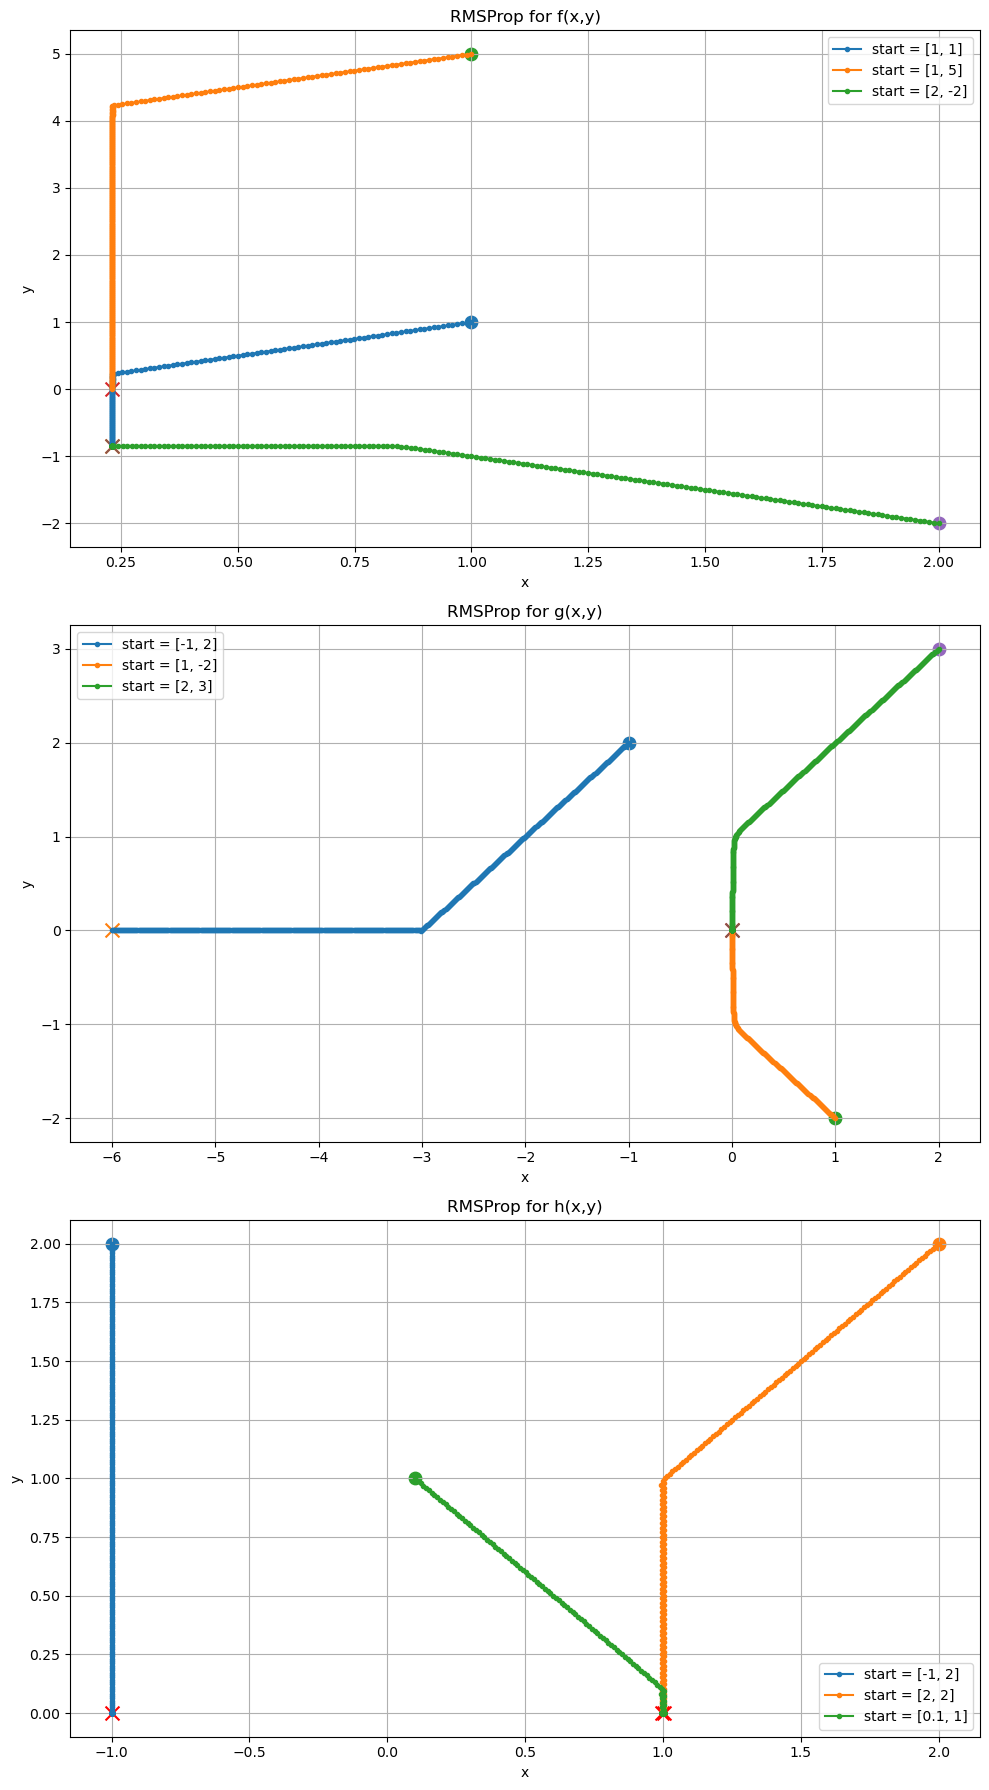

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

starts_f = [[1,1], [1,5], [2,-2]]
ax = axes[0]
for history, start in zip(histories_f, starts_f):
    ax.plot(history[:, 0], history[:, 1], marker="o", markersize=3, label=f"start = {start}")
    ax.scatter(history[0, 0], history[0, 1], s=80)
    ax.scatter(history[-1, 0], history[-1, 1], marker="x", s=100)

ax.set_title("RMSProp for f(x,y)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)
ax.legend()

starts_g = [[-1,2], [1,-2], [2,3]]
ax = axes[1]
for history, start in zip(histories_g, starts_g):
    ax.plot(history[:, 0], history[:, 1], marker="o", markersize=3, label=f"start = {start}")
    ax.scatter(history[0, 0], history[0, 1], s=80)
    ax.scatter(history[-1, 0], history[-1, 1], marker="x", s=100)

ax.set_title("RMSProp for g(x,y)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)
ax.legend()

starts_h = [[-1,2], [2,2], [0.1,1]]
ax = axes[2]
for history, start in zip(histories_h, starts_h):
    ax.plot(history[:, 0], history[:, 1], marker="o", markersize=3, label=f"start = {start}")
    ax.scatter(history[0, 0], history[0, 1], s=80)
    ax.scatter(history[-1, 0], history[-1, 1], marker="x", s=100, color = 'red')

ax.set_title("RMSProp for h(x,y)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

#### 3.5. (3 балла)

Отрисуйте графики самих функций еще раз. На данные графики нанесите движение алгоритма от исходных точек к финальной точке разными цветами. Там, где они есть у функции, нанесите на графики истинные локальные минимумы функций в виде отдельных точек, а также подпишите их в виде текста на графике. Все графики строятся на трёх множествах осей, размещенных вертикально на одном полотне — свои оси для каждой функции.

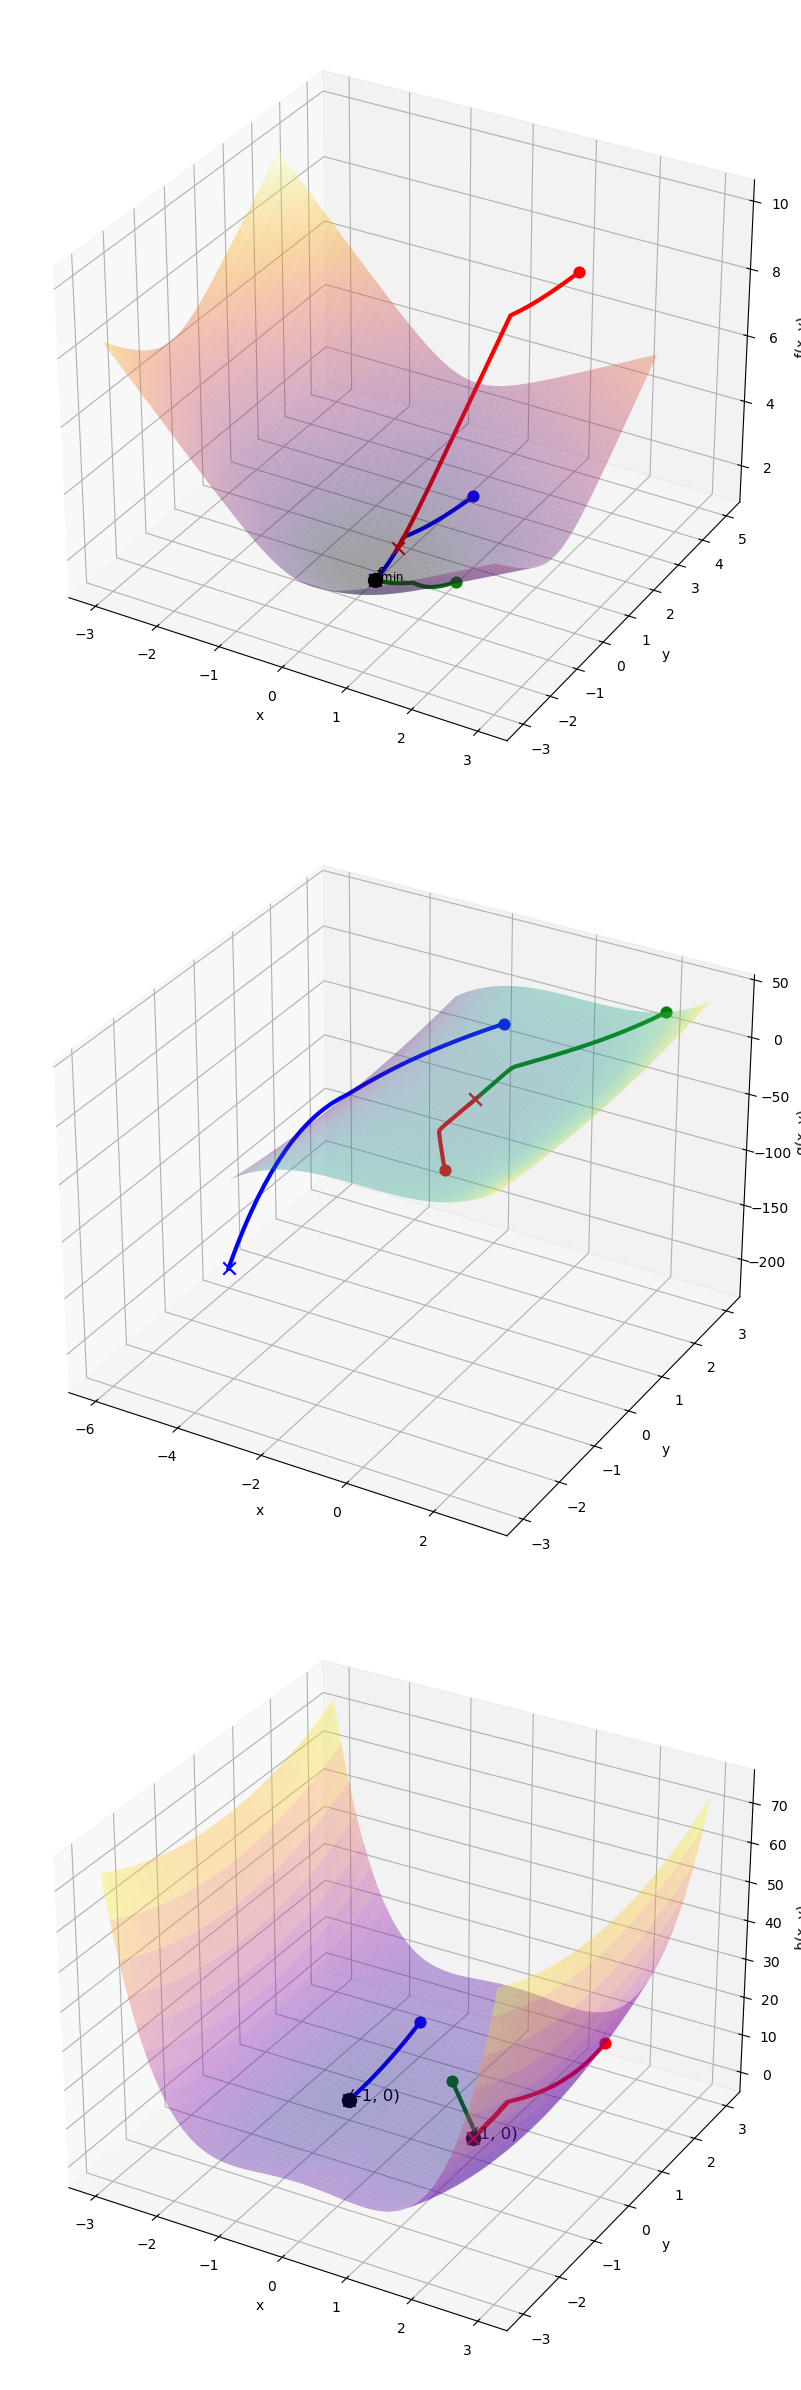

In [23]:
fig = plt.figure(figsize=(14, 24))
ax1 = fig.add_subplot(3, 1, 1, projection="3d")

x = np.linspace(-3, 3, 150)
y = np.linspace(-3, 3, 150)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

ax1.plot_surface(X, Y, Z, cmap="inferno", alpha=0.35)
colors = ["blue", "red", "green", "orange", "purple"]
for history, color in zip(histories_f, colors):
    ax1.plot(
        history[:, 0],
        history[:, 1],
        f(history[:, 0], history[:, 1]),
        color=color,
        linewidth=3
    )
    ax1.scatter(
        history[0, 0],
        history[0, 1],
        f(history[0, 0], history[0, 1]),
        color=color,
        s=60
    )
    ax1.scatter(
        history[-1, 0],
        history[-1, 1],
        f(history[-1, 0], history[-1, 1]),
        color=color,
        marker="x",
        s=80
    )

x_min_f = np.log(2) / 3
y_min_f = -(1 + np.log(2)) / 2
z_min_f = f(x_min_f, y_min_f)
ax1.scatter(x_min_f, y_min_f, z_min_f, color="black", s=100)
ax1.text(
    x_min_f,
    y_min_f,
    z_min_f,
    r"$f_{\min}$",
    color="black",
    fontsize=12
)

ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("f(x, y)")



ax2 = fig.add_subplot(3, 1, 2, projection="3d")

x = np.linspace(-3, 3, 150)
y = np.linspace(-3, 3, 150)
X, Y = np.meshgrid(x, y)
Z = g(X, Y)

ax2.plot_surface(X, Y, Z, cmap="viridis", alpha=0.35)
for history, color in zip(histories_g, colors):
    ax2.plot(
        history[:, 0],
        history[:, 1],
        g(history[:, 0], history[:, 1]),
        color=color,
        linewidth=3
    )
    ax2.scatter(
        history[0, 0],
        history[0, 1],
        g(history[0, 0], history[0, 1]),
        color=color,
        s=60
    )
    ax2.scatter(
        history[-1, 0],
        history[-1, 1],
        g(history[-1, 0], history[-1, 1]),
        color=color,
        marker="x",
        s=80
    )

ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("g(x, y)")


ax3 = fig.add_subplot(3, 1, 3, projection="3d")
x = np.linspace(-3, 3, 150)
y = np.linspace(-3, 3, 150)
X, Y = np.meshgrid(x, y)
Z = h(X, Y)

ax3.plot_surface(X, Y, Z, cmap="plasma", alpha=0.35)
for history, color in zip(histories_h, colors):
    ax3.plot(
        history[:, 0],
        history[:, 1],
        h(history[:, 0], history[:, 1]),
        color=color,
        linewidth=3
    )
    ax3.scatter(
        history[0, 0],
        history[0, 1],
        h(history[0, 0], history[0, 1]),
        color=color,
        s=60
    )
    ax3.scatter(
        history[-1, 0],
        history[-1, 1],
        h(history[-1, 0], history[-1, 1]),
        color=color,
        marker="x",
        s=80
    )


mins_h = [(-1, 0), (1, 0)]
for x_min_h, y_min_h in mins_h:
    z_min_h = h(x_min_h, y_min_h)
    ax3.scatter(x_min_h, y_min_h, z_min_h, color="black", s=100)
    ax3.text(
        x_min_h,
        y_min_h,
        z_min_h,
        f"({x_min_h}, {y_min_h})",
        color="black",
        fontsize=12
    )

ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("h(x, y)")

plt.tight_layout()
plt.show()

### Задание 4

#### Масштабирование на многомерный случай (4 балла)

Удостоверьтесь в том, что ваша функция `get_min_with_rmsprop` из прошлого задания работает не только с функциями от двух переменных, но и с функциями от произвольного числа переменных. При необходимости внесите в функцию корректировки ниже.

Придумайте любую функцию от 5 переменных, у которой есть какой-нибудь минимум (например, самое простое, точка $(0, 0, 0, 0, 0)$) и запустите градиентный спуск с RMSProp для этой функции. Проверьте, что градиентный спуск действительно сходится в правильную точку экстремума.

In [ ]:
# Ваш код здесь